<a href="https://colab.research.google.com/github/aryashivakumar/dataScience/blob/main/Unit7/Arya_Kumar_Unit7ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fitting Curves: Concepts

What you'll do:

- Answer questions about what a GP is, and its relationship to GLMs and splines.
- Practice applying each of: polynomial modeling, b splines, and GPs
- You'll get a chance to read about and try to comprehend a more standard implementation of a GP.

Have fun!

**Task1**:

Why would you ever want to include a polynomial element in a model you built? What's the benefit of using polynomials to model?

You would want to utilize a polynomial element in order to fit the data more closely in some cases. This is used also in the case that overfitting isn't a potential issue.

**Task2**:

Why would you ever NOT want to include a polynomial element in a model you built?

You would not want to use a polynomial elemnt in a model in the case that a linear model would help model the relationship better or if you need the model to create predictions on data it isn't trained on.

**Task3**:

What's the point of using b splines?

B splines are similar to polynomial models however they help lower overfitting.  They allow for flexible curves for complicated patterns.

**Task4**:

Describe what a Gaussian Process is, in your own words. *Don't worry about being correct, just try to explain it to yourself*. I will not grade this question for accuracy.

Guassian Process is a super flexible curve that determines its shape based on how points relate to other ones?

**Task5**:

Fit three models to the howell data (from Unit5ExercisesSF): polynomial, b splines, and Gaussian Process.

Plot the posterior predictive check on a scatter plot, as is standard/required.

Hint: Distributional models (variable variance) work better on the howell data.


In [ ]:
!pip install preliz
!pip install bambi


import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import preliz as pz
import pymc as pm
import bambi as bmb

In [2]:
howellData = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/howell.csv')

In [3]:

howellData

,height,weight,age,male
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0
...,...,...,...,...
539,145.415,31.127751,17.0,1
540,162.560,52.163080,31.0,1
541,156.210,54.062497,21.0,0
542,71.120,8.051258,0.0,1


In [ ]:
model_poly_1=bmb.Model("height ~ weight", howellData)
idata_poly_1 = model_poly_1.fit()

In [ ]:
model_poly_4 = bmb.Model("height ~ poly(weight, degree=4)", howellData)
idata_poly_4 = model_poly_4.fit(posterior_predictive=True)

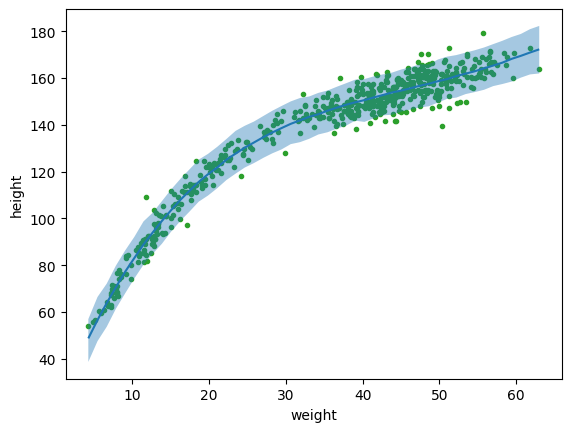

In [6]:
bmb.interpret.plot_predictions(model_poly_4, idata_poly_4, "weight", pps=True)
plt.plot(howellData.weight, howellData.height, "C2.", zorder=-3)


In [ ]:
idata_poly_4 = model_poly_4.fit()

model_poly_4.predict(
    idata_poly_4,
    kind="pps",
    inplace=True
)

idata_poly_4

In [ ]:
idata_poly_4 = model_poly_4.fit()

idata_poly_4 = model_poly_4.predict(
    idata_poly_4,
    kind="response",
    inplace=False
)

idata_poly_4

<Axes: xlabel='height'>

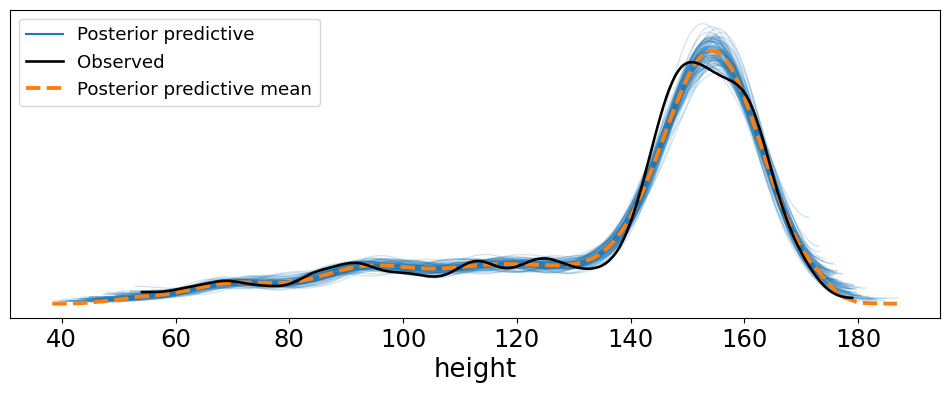

In [9]:
az.plot_ppc(idata_poly_4, num_pp_samples=100, figsize=(12, 4))

In [ ]:
num_knots = 6
min_number = howellData.weight.min()
max_number = howellData.weight.max()
knots = np.linspace(min_number, max_number, num_knots+2)[1:-1]
model_spline_t = bmb.Model("height ~ bs(weight, degree=3, knots=knots)", howellData)
idata_spline_t = model_spline_t.fit()

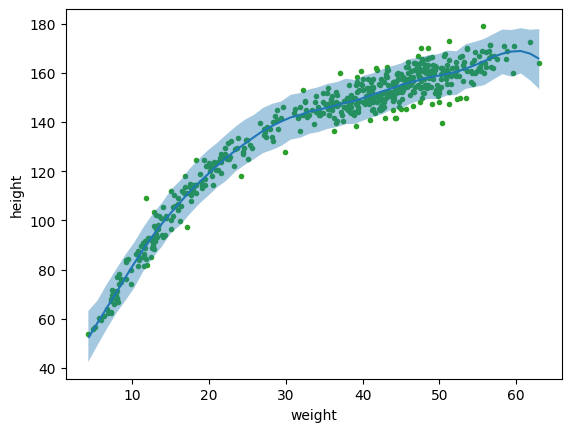

In [11]:
bmb.interpret.plot_predictions(model_spline_t, idata_spline_t, "weight", pps=True)
plt.plot(howellData.weight, howellData.height, "C2.", zorder=-3)

In [12]:
#convert from pandas to numpy array
weight = howellData["weight"].values
height = howellData["height"].values[:,None]

In [32]:
#ig stands for inverse gamma
def get_ig_params(x_vals, l_b=None, u_b=None, mass=0.96, plot=False):
    """
    Returns a weakly informative prior for the length-scale parameter of the GP kernel.
    """

    differences = np.abs(np.subtract.outer(x_vals, x_vals))
    if l_b is None:
        l_b = np.min(differences[differences != 0]) * 2
    if u_b is None:
        u_b = np.max(differences) / 1.5

    dist = pz.InverseGamma()
    pz.maxent(dist, l_b, u_b, mass, plot=plot)

    return dict(zip(dist.param_names, dist.params))


In [33]:

m, c = pm.gp.hsgp_approx.approx_hsgp_hyperparams(
    x_range=[min_number, max_number], lengthscale_range=[1, 30], cov_func="ExpQuad"
)

print("Recommended smallest number of basis vectors (m):", m)
print("Recommended smallest scaling factor (c):", np.round(c, 1))


Recommended smallest number of basis vectors (m): 168
Recommended smallest scaling factor (c): 3.3


In [ ]:
prior_gp = {
    "sigma": bmb.Prior("Gamma", mu=1, sigma=0.01),
    "ell": bmb.Prior("InverseGamma", **get_ig_params(height))
}

priors = {
    "hsgp(height, m=168, c=8.0)": prior_gp,
    "alpha": bmb.Prior("HalfNormal", sigma=1)
}

model_hsb = bmb.Model("weight ~ 0 + hsgp(height, m=168, c=8.0)", howellData, priors=priors)
idata_hsb = model_hsb.fit()

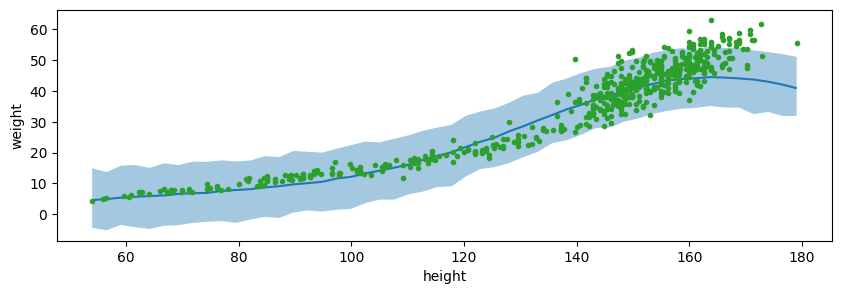

In [42]:
_, ax = bmb.interpret.plot_predictions(model_hsb, idata_hsb, ["height"],
                                       pps = True,
                                       fig_kwargs={"figsize": (10, 3)})
ax[0].plot(howellData["height"].values, howellData["weight"].values, "C2.")

Used some gemini for the graph showcased above as I had some trouble running it, had issues with plotting the graph due to an issue with the fit() section in the code. Was able to fix this after speaking to Mr. A

**Task6**:

Read the article on the pymc website about GP implementation on the Mauna Loa CO$_{2}$ data combined with CO$_{2}$ ice core data from the south pole.
[Link here.](https://www.pymc.io/projects/examples/en/latest/gaussian_processes/GP-MaunaLoa2.html)

Write down one thing you learned about GPs from reading the article.

Note: You probably won't understand much in this article--I had to read it about five times before I figured out what was going on. The points of this task are to: hammer home that good GP implementations are extremely technical, and increasure your exposure to the kinds of problems traditional GPs are good at solving.

Whenutilizing Guassian Processes on real-world data, you often are required to model the uncertainty not just in the y values but also in the inputs. Specifically, because the ice core measurements don't have exact dates, it looks like the observation times were treated as uncertain and the model laerned about them parallel with the GP.

"Since the ice core data isn’t measured accurately, it won’t be possible to backcast the seasonal component unless we model uncertainty in x."
“To model uncertainty in x, or time, we place a prior distribution over each of the observation dates.”

**Task7**:

Describe your favorite graph from the article in the previous task with as much technical detail as you can muster.

Explain why its your favorite.

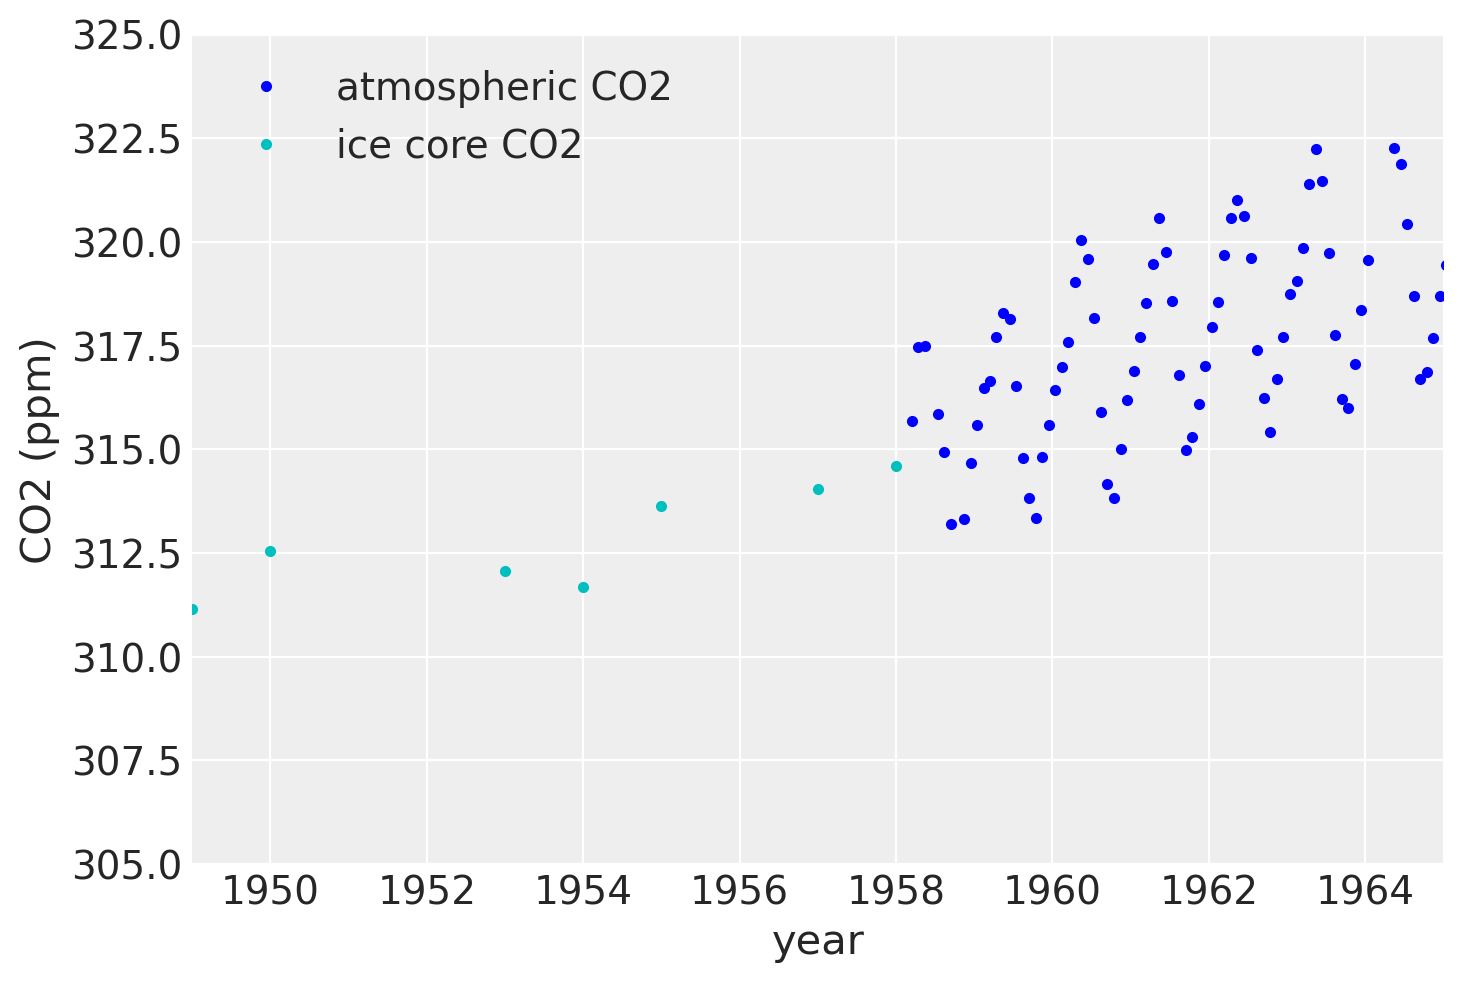

This graph was my favorite because it was the simplest at first to understand and I was able to clearly understnad the issue. The atmospheric data is much more precise whereas the ice core data is less precise (less dots), indicating the problem is less accuracy for ice core data before the kernel and covariance functions used.